# Лабораторная работа №5: Представление графа. Обход графа

Лабораторная работа состоит из 6 задач. Для каждой задачи вы должны дать: \
1) код, где первый комментарий - асимптотическая сложность алгоритма (по времени и по памяти!) \

2) скрин с окнутой задачей из тестирующей системы\

3) ВАШЕ (не гпт) описание работы (так называемая, интуиция / идея решения).

Задача засчитывается, если три пункта выполнены честно.

Если вдруг, обнаружится плагиат / гпт решения - аннулируется задача без возможности апелляции.

# Приступим


## Задача: удаление клеток ([ссылка](https://acmp.ru/asp/do/index.asp?main=task&id_course=2&id_section=21&id_topic=50&id_problem=1013)) [1 балл]

Из прямоугольного листа клетчатой бумаги размером N строк и M столбцов удалили некоторые клетки. Если клетка не была удалена, она обозначается символом `#`, а если удалена – символом `.`. Остальные клетки, которые имеют общую сторону, считаются соединёнными и образуют один кусок бумаги. Необходимо определить, на сколько частей распадётся оставшаяся часть листа после удаления клеток.

---

## Входные данные

- В первой строке входного файла `INPUT.TXT` содержатся два целых числа N и M (1 ≤ N, M ≤ 100) – количество строк и столбцов листа.
- Далее следуют N строк, каждая из которых содержит M символов. Символ `#` означает, что клетка осталась, а символ `.` – что клетка была удалена.

---

## Выходные данные

Выведите одно число – количество отдельных кусков, на которые распадётся оставшаяся часть листа. Две клетки считаются принадлежащими одному куску, если они имеют общую сторону.

---

## Пример

**Входные данные:**
```
4 8
#.##.#.#
......##
#.###.##
##.##.##
```

**Выходные данные:**
```
6
```

In [ ]:
# Асимптотическая сложность по времени - О(N × M)
# Асимптотическая сложность по памяти - O(N × M)

# ВАШ КОД

def read_input():
    with open("INPUT.TXT", "r") as f:
        n, m = map(int, f.readline().split())
        grid = [list(f.readline().strip()) for _ in range(n)]
    return n, m, grid

def write_output(result):
    with open("OUTPUT.TXT", "w") as f:
        f.write(str(result) + "\n")

def count_components(n, m, grid):
    visited = [[False] * m for _ in range(n)]
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    def dfs(x, y):
        stack = [(x, y)]
        visited[x][y] = True
        while stack:
            cx, cy = stack.pop()
            for dx, dy in directions:
                nx, ny = cx + dx, cy + dy
                if 0 <= nx < n and 0 <= ny < m:
                    if not visited[nx][ny] and grid[nx][ny] == '#':
                        visited[nx][ny] = True
                        stack.append((nx, ny))

    components = 0
    for i in range(n):
        for j in range(m):
            if grid[i][j] == '#' and not visited[i][j]:
                dfs(i, j)
                components += 1
    return components

if __name__ == "__main__":
    n, m, grid = read_input()
    result = count_components(n, m, grid)
    write_output(result)



### ВАША интуиция

Это классическая задача на поиск компонент связности в графе. Решить её можно с помощью поиска в глубину (DFS)

### ВАШ скрин ОКнутой задачи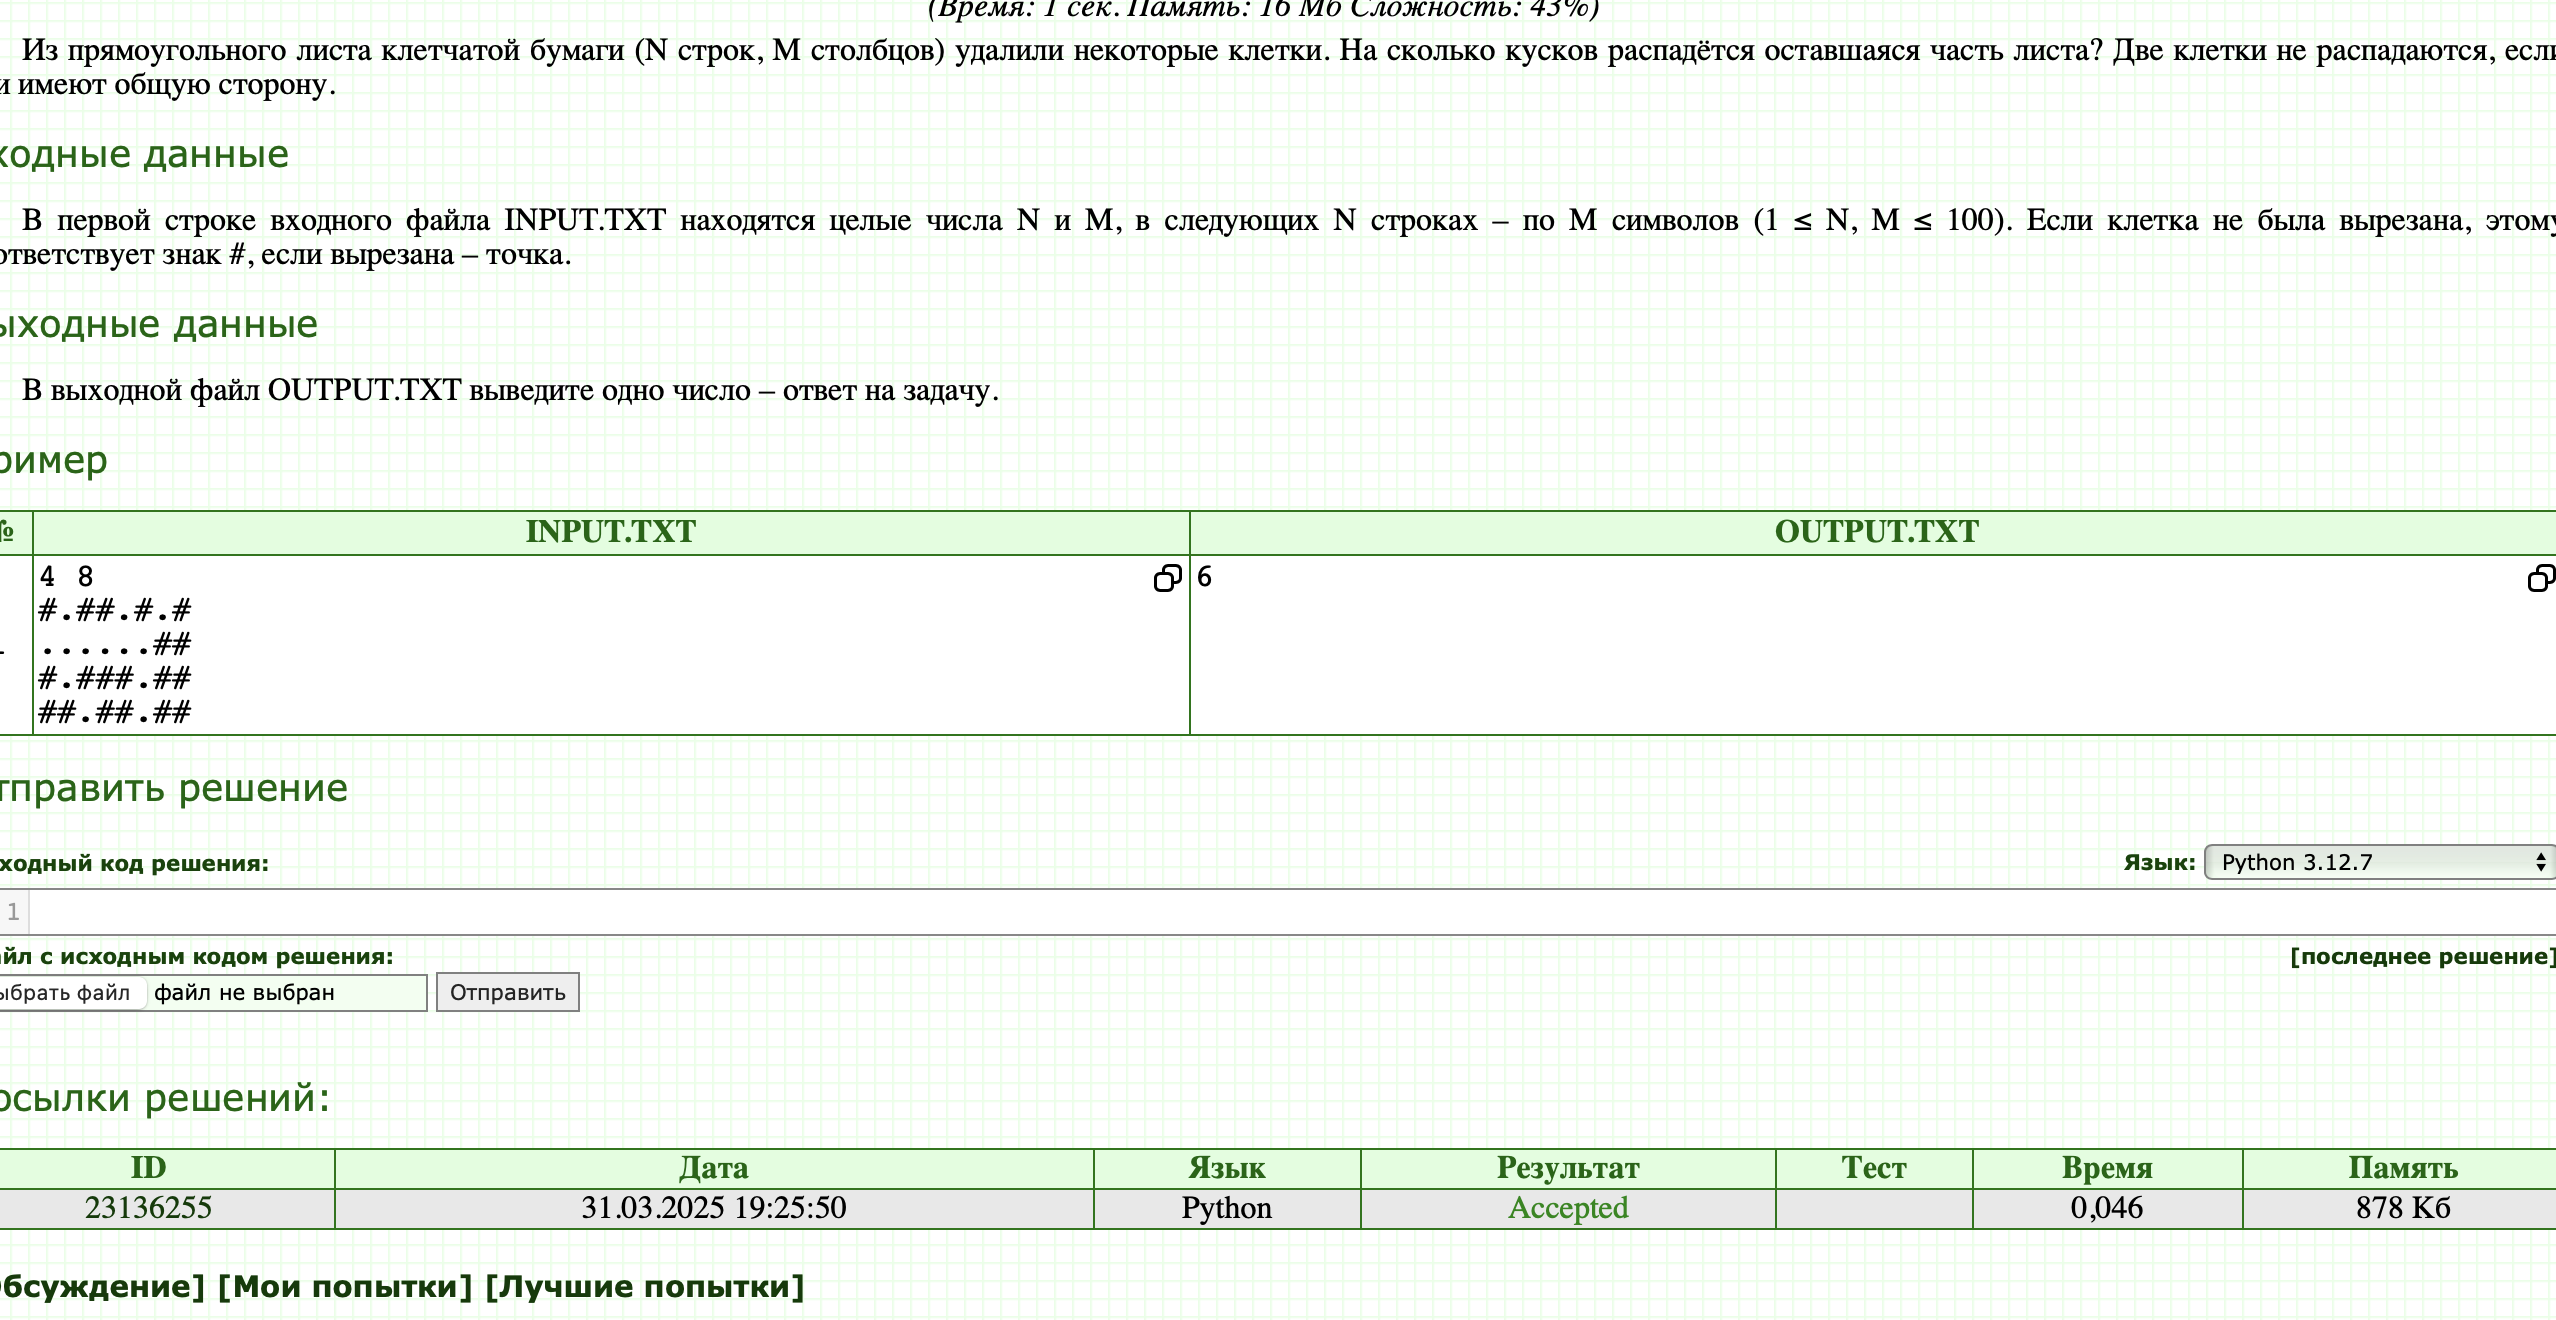

## Задача: Укладка плитки ([ссылка](https://acmp.ru/asp/do/index.asp?main=task&id_course=2&id_section=21&id_topic=50&id_problem=641)) [1 балл]

Бригаде строителей поручили уложить квадратной плиткой пол в виде шахматного узора на кухне. Однако при укладке возникли недочёты: в некоторых местах плитки одного цвета оказались расположены рядом (имеют общую сторону). По заданной схеме замощения нужно определить, какое минимальное число строителей могло участвовать в укладке плитки.

**Идея решения:**  
Предполагается, что каждый строитель укладывал плитку по своему участку, не взаимодействуя с другими. Ошибки в узоре (соседние плитки одного цвета) могут возникать, если работы выполнялись несколькими строителями с различными шаблонами укладки. Задача сводится к разбиению плоскости на части, где в каждом участке плитки выложены единообразно (без нарушений шахматного чередования), и минимальное число таких участков соответствует минимальному числу строителей.

---

## Входные данные

Входной файл `INPUT.TXT` содержит 8 строк, каждая из которых состоит из 8 символов `W` и `B`:
- Символ `W` обозначает белую плитку.
- Символ `B` обозначает чёрную плитку.

---

## Выходные данные

Выведите одно число — минимальное число строителей, которые могли участвовать в укладке плитки, чтобы получить такое замощение.

---

## Пример

**Входные данные:**
```
WBWBWBBW
BWBBWBWB
WBWWBWBW
WBWWBWWB
BWBBWBWB
WBWBWWBW
BWBWBBWB
WBWBWWBW
```

**Выходные данные:**
```
4
```

In [ ]:
# Асимптотическая сложность по времени - О(N × M)
# Асимптотическая сложность по памяти - O(N × M)

# ВАШ КОД

def read_input():
    with open("INPUT.TXT", "r") as f:
        grid = [list(f.readline().strip()) for _ in range(8)]
    return grid

def write_output(result):
    with open("OUTPUT.TXT", "w") as f:
        f.write(str(result) + "\n")

# Функция для подсчёта связных компонент в матрице "error"
def count_components(error):
    n, m = 8, 8
    visited = [[False]*m for _ in range(n)]
    directions = [(-1,0), (1,0), (0,-1), (0,1)]
    components = 0

    def dfs(i, j, val):
        stack = [(i, j)]
        visited[i][j] = True
        while stack:
            ci, cj = stack.pop()
            for di, dj in directions:
                ni, nj = ci + di, cj + dj
                if 0 <= ni < n and 0 <= nj < m:
                    if not visited[ni][nj] and error[ni][nj] == val:
                        visited[ni][nj] = True
                        stack.append((ni, nj))

    for i in range(n):
        for j in range(m):
            if not visited[i][j]:
                dfs(i, j, error[i][j])
                components += 1
    return components

def compute_min_builders(grid):
    n, m = 8, 8
    results = []
    for top_left in ['W', 'B']:
        ideal = [['']*m for _ in range(n)]
        for i in range(n):
            for j in range(m):
                if top_left == 'W':
                    ideal[i][j] = 'W' if (i+j)%2==0 else 'B'
                else:
                    ideal[i][j] = 'B' if (i+j)%2==0 else 'W'
        error = [[0]*m for _ in range(n)]
        for i in range(n):
            for j in range(m):
                error[i][j] = 0 if grid[i][j] == ideal[i][j] else 1
        comp = count_components(error)
        results.append(comp)
    return min(results)

if __name__ == "__main__":
    grid = read_input()
    result = compute_min_builders(grid)
    write_output(result)



### ВАША интуиция
Мы разбиваем поле на связные области, где плитки либо строго следуют шахматному узору, либо полностью его инвертируют, и минимальное число таких областей соответствует минимальному числу строителей.

### ВАШ скрин ОКнутой задачи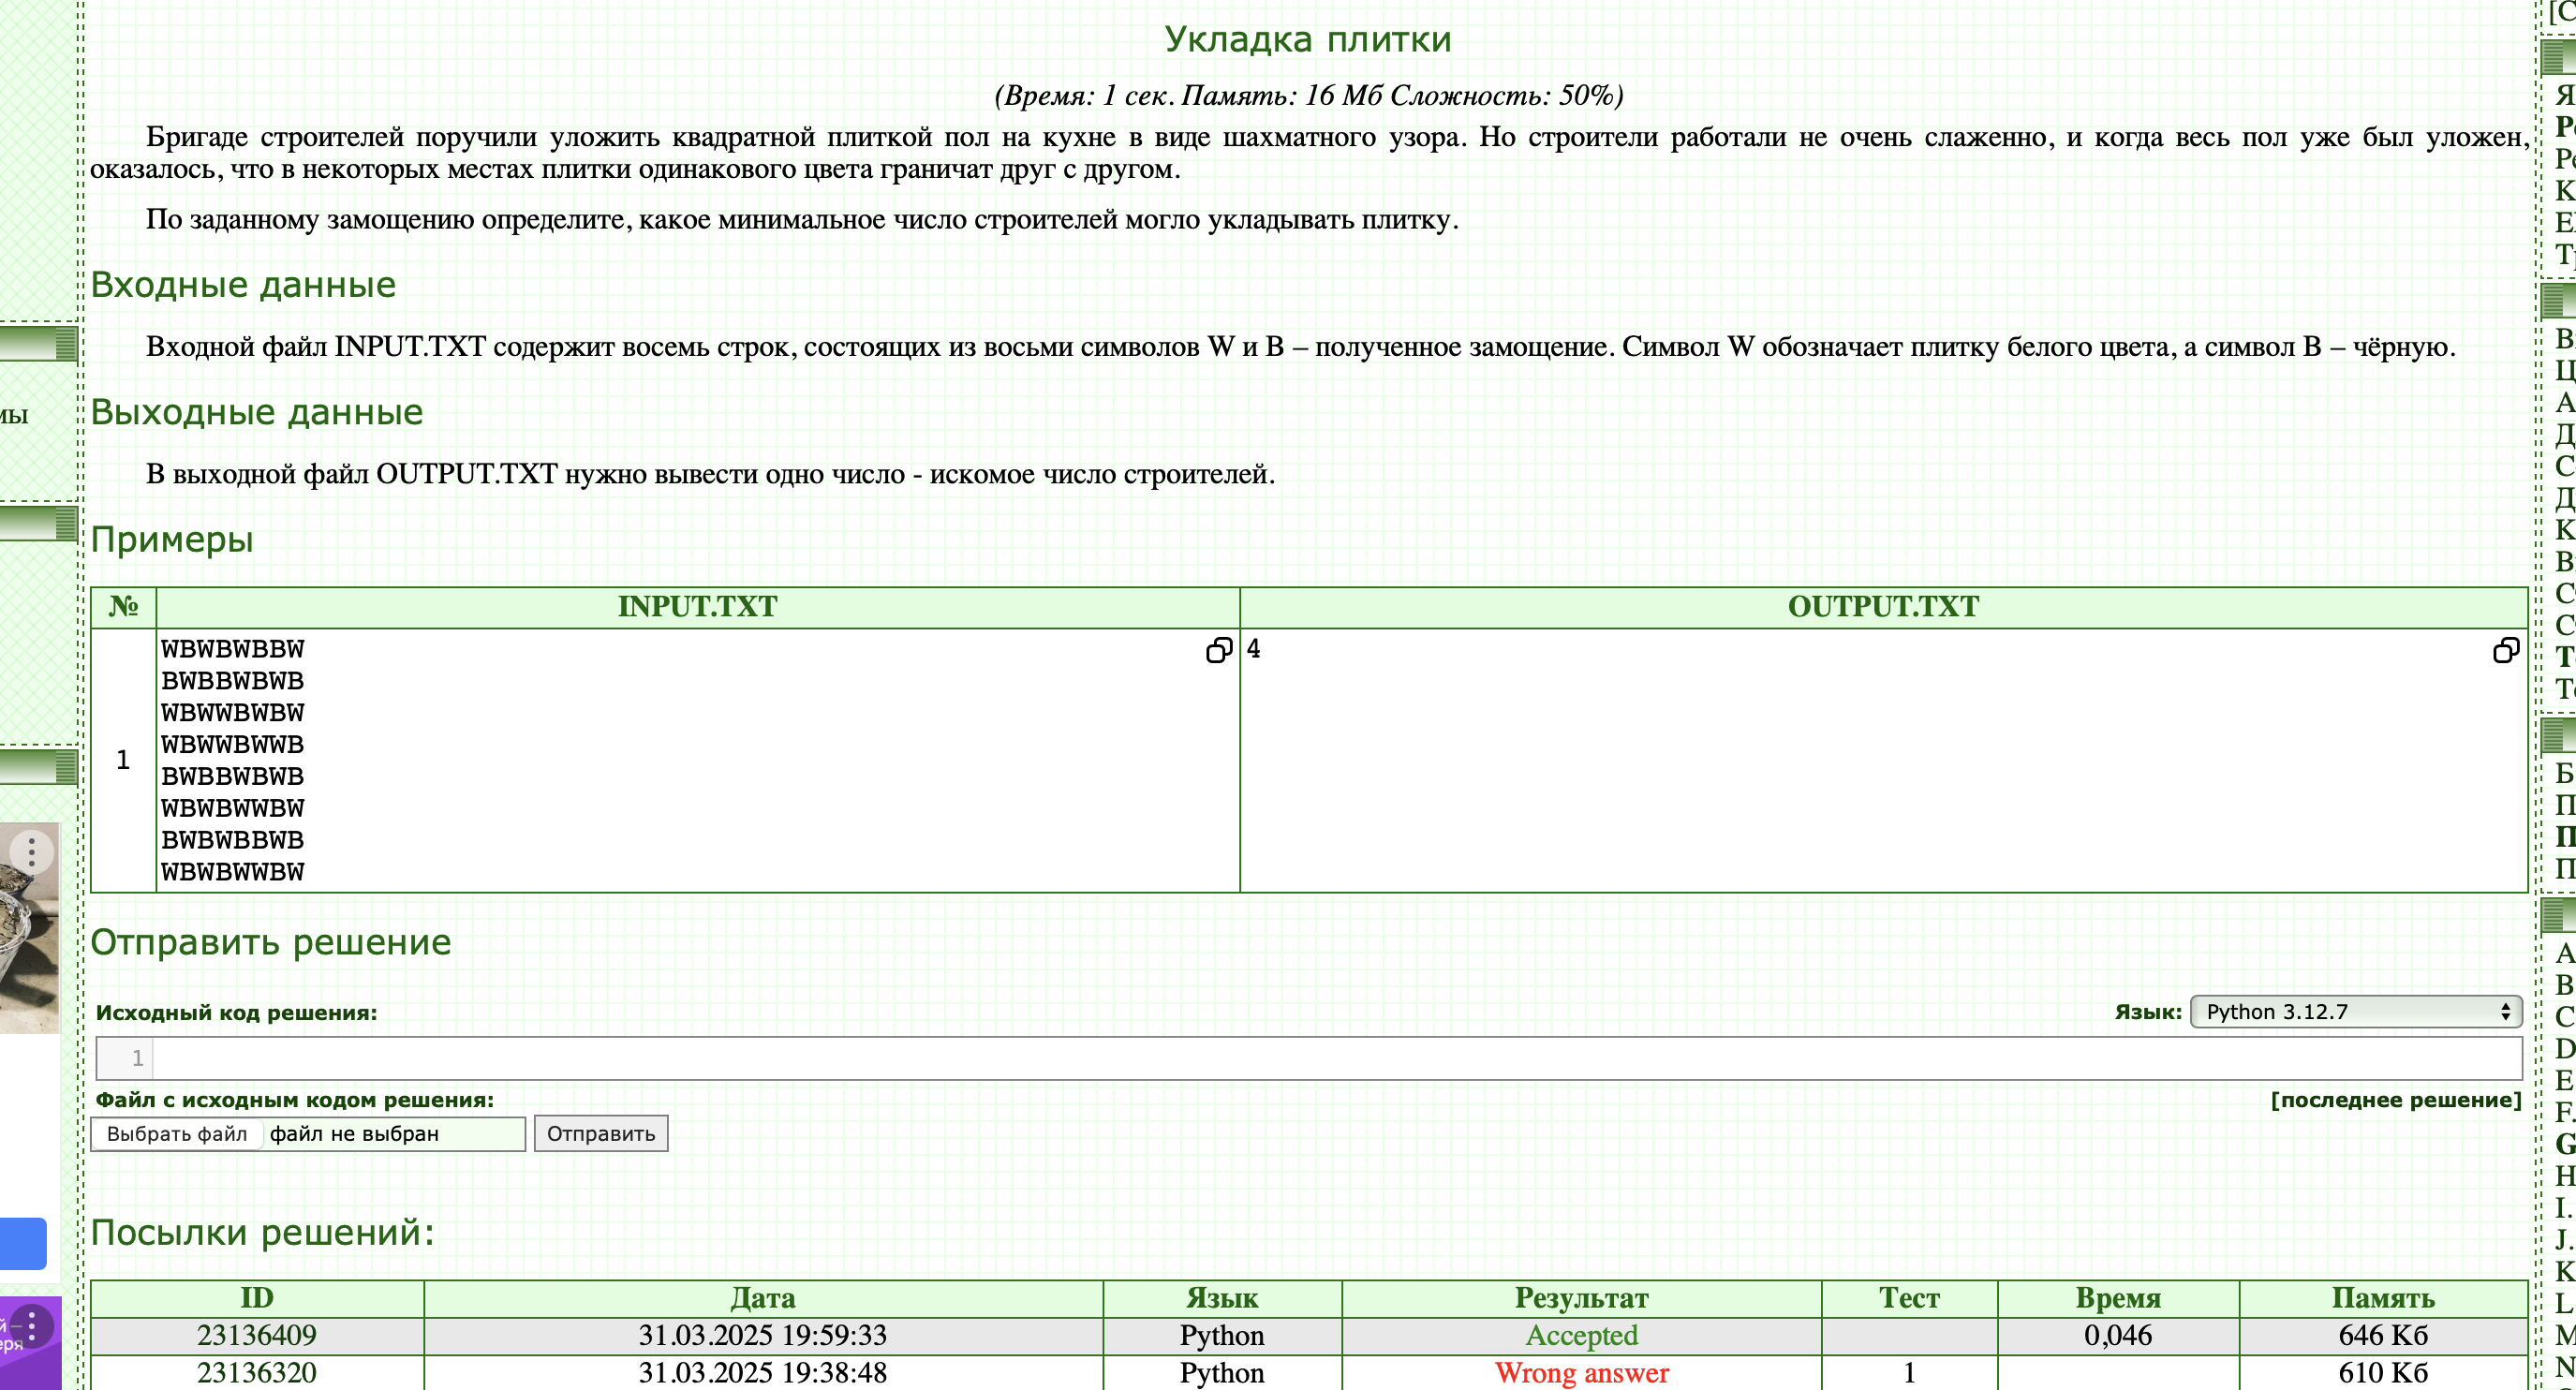

## Задача: Раздел империи ([ссылка](https://acmp.ru/asp/do/index.asp?main=task&id_course=2&id_section=21&id_topic=50&id_problem=1217)) [1 балл]

Великая империя прошлого состояла из N городов, соединённых M двусторонними дорогами таким образом, что между любыми двумя городами существовал путь (возможно, через другие города). При этом:
- Между одной и той же парой городов может проходить несколько дорог.
- Дороги могут выходить и входить в один и тот же город.

Со временем K городов усилились и возвысились над остальными, между ними начались междоусобицы, и в результате империя распалась на K государств, в каждом из которых столицей стал один из усиленных городов.

Из древних источников неизвестно, какой город каким государством оказался после распада империи. Известно, однако, что в каждом из образованных государств, как и в великой империи, между любой парой городов существует путь (через другие города того же государства), и каждый город империи вошёл ровно в одно государство.

**Задача:** Восстановить карту, то есть определить разбиение городов империи по государствам. Для каждого усиленного города (столицы) необходимо вывести список городов, принадлежащих соответствующему государству. Если вариантов решения несколько, можно вывести любой.

---

## Входные данные

- Первая строка входного файла `INPUT.TXT` содержит два целых числа:
  - N (1 ≤ N ≤ 1000) — количество городов;
  - M (N-1 ≤ M ≤ 10^5) — количество дорог.
- Следующие M строк содержат описание дорог. Каждая строка состоит из двух целых чисел x_i и y_i (1 ≤ x_i, y_i ≤ N), означающих, что дорога соединяет города с номерами x_i и y_i.
- Следующая строка содержит целое число K (1 ≤ K ≤ N) — количество усиленных городов (столиц).
- Последняя строка содержит K различных целых чисел c_i (1 ≤ c_i ≤ N) — номера городов, ставших столицами.

---

## Выходные данные

В выходном файле `OUTPUT.TXT` для каждого из K усиленных городов необходимо вывести следующее:
- В первой строке — количество городов в государстве, где столицей является этот город.
- Во второй строке — номера городов, входящих в это государство.

Порядок вывода для усиленных городов должен соответствовать порядку их перечисления во входном файле.

---

## Пример

**Входные данные:**
```
3 2
1 2
2 3
2
1 3
```

**Выходные данные:**
```
2
1 2
1
3
```

In [ ]:
# Асимптотическая сложность по времени - O(N + M)
# Асимптотическая сложность по памяти - O(N + M)

# ВАШ КОД

from collections import deque, defaultdict

def read_input():
    with open("INPUT.TXT", "r") as f:
        n, m = map(int, f.readline().split())
        graph = [[] for _ in range(n + 1)]
        for _ in range(m):
            u, v = map(int, f.readline().split())
            graph[u].append(v)
            graph[v].append(u)
        k = int(f.readline())
        capitals = list(map(int, f.readline().split()))
    return n, graph, k, capitals

def write_output(groups, capitals):
    with open("OUTPUT.TXT", "w") as f:
        for cap in capitals:
            cities = groups[cap]
            f.write(str(len(cities)) + "\n")
            f.write(" ".join(map(str, sorted(cities))) + "\n")

def divide_empire(n, graph, capitals):
    owner = [0] * (n + 1)  # owner[i] = номер столицы, которой принадлежит город i
    queue = deque()

    for cap in capitals:
        owner[cap] = cap
        queue.append(cap)

    while queue:
        current = queue.popleft()
        for neighbor in graph[current]:
            if owner[neighbor] == 0:
                owner[neighbor] = owner[current]
                queue.append(neighbor)

    # Сгруппировать города по столицам
    groups = defaultdict(list)
    for city in range(1, n + 1):
        groups[owner[city]].append(city)

    return groups

if __name__ == "__main__":
    n, graph, k, capitals = read_input()
    groups = divide_empire(n, graph, capitals)
    write_output(groups, capitals)



### ВАША интуиция
Нам нужно разделить связный граф на K компонент, каждая из которых содержит одну столицу и включает все города, к которым можно добраться раньше других столиц, распространяясь из столиц одновременно в ширину (BFS).

### ВАШ скрин ОКнутой задачи

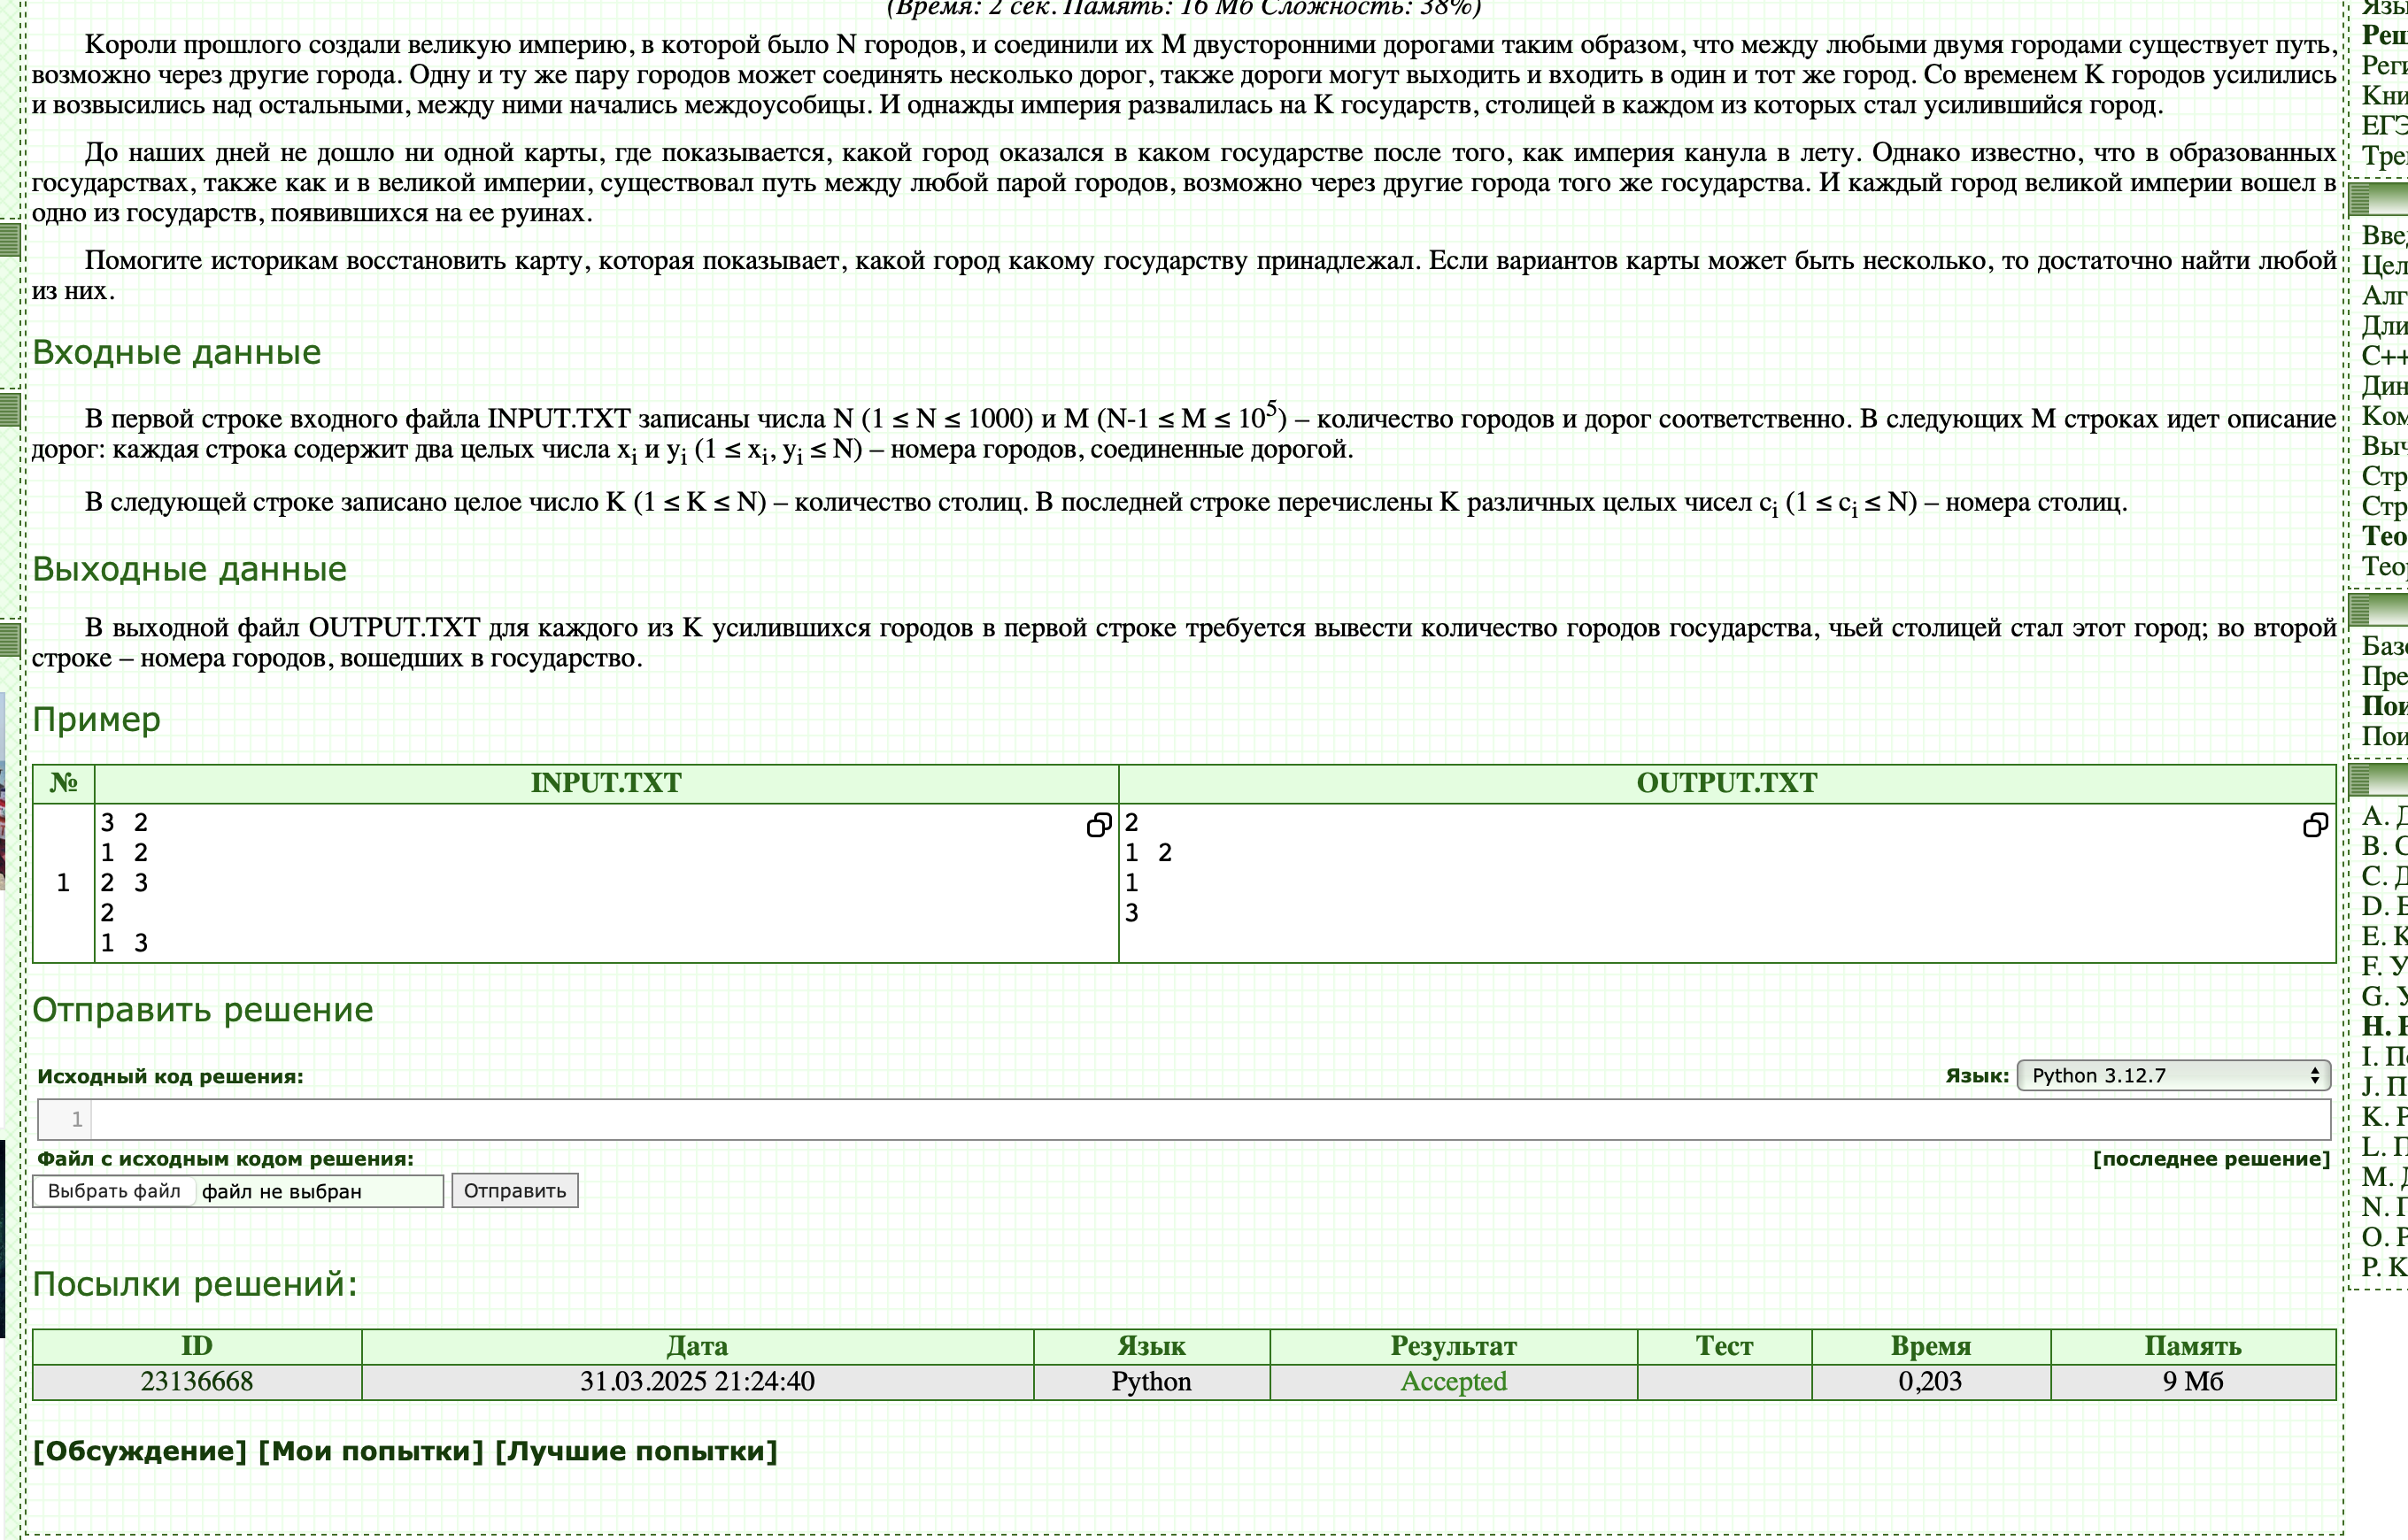

## Задача: Табличка ([ссылка](https://acmp.ru/asp/do/index.asp?main=task&id_course=2&id_section=21&id_topic=51&id_problem=650)) [1 балл]
Вам дана таблица, состоящая из N строк и M столбцов. В каждой клетке таблицы содержится число 0 или 1. Расстояние между клетками с координатами (x₁, y₁) и (x₂, y₂) определяется как |x₁ - x₂| + |y₁ - y₂|.

**Задача:** Построить новую таблицу того же размера, в которой для каждой клетки будет указано расстояние до ближайшей клетки, содержащей 1 (из исходной таблицы). Гарантируется, что в исходной таблице есть хотя бы одна клетка с единицей.

---

## Входные данные

- Первая строка входного файла `INPUT.TXT` содержит два натуральных числа N и M (N, M ≤ 100) — количество строк и столбцов таблицы.
- Далее следуют N строк, каждая содержащая M чисел (0 или 1) — элементы таблицы.

---

## Выходные данные

Выведите в выходной файл `OUTPUT.TXT` N строк, каждая из которых содержит M чисел — элементы искомой таблицы, где каждое число является расстоянием от соответствующей клетки исходной таблицы до ближайшей клетки с единицей.

---

## Пример

**Входные данные:**
```
2 3
0 0 1
1 0 0
```

**Выходные данные:**
```
1 1 0
0 1 1
```

In [ ]:
# Асимптотическая сложность по времени - O(N × M)
# Асимптотическая сложность по памяти - O(N × M)

# ВАШ КОД

from collections import deque

def read_input():
    with open("INPUT.TXT", "r") as f:
        n, m = map(int, f.readline().split())
        grid = [list(map(int, f.readline().split())) for _ in range(n)]
    return n, m, grid

def write_output(result):
    with open("OUTPUT.TXT", "w") as f:
        for row in result:
            f.write(" ".join(map(str, row)) + "\n")

def bfs_distance(n, m, grid):
    dist = [[-1] * m for _ in range(n)]
    queue = deque()

    for i in range(n):
        for j in range(m):
            if grid[i][j] == 1:
                dist[i][j] = 0
                queue.append((i, j))

    dirs = [(-1,0), (1,0), (0,-1), (0,1)]

    while queue:
        x, y = queue.popleft()
        for dx, dy in dirs:
            nx, ny = x + dx, y + dy
            if 0 <= nx < n and 0 <= ny < m and dist[nx][ny] == -1:
                dist[nx][ny] = dist[x][y] + 1
                queue.append((nx, ny))

    return dist

if __name__ == "__main__":
    n, m, grid = read_input()
    result = bfs_distance(n, m, grid)
    write_output(result)



### ВАША интуиция
Предстваим, что из всех единичек одновременно пошла волна по клеткам, и мы просто сохраняем, на каком расстоянии она дошла до каждой клетки — и это и есть ответ.

### ВАШ скрин ОКнутой задачи

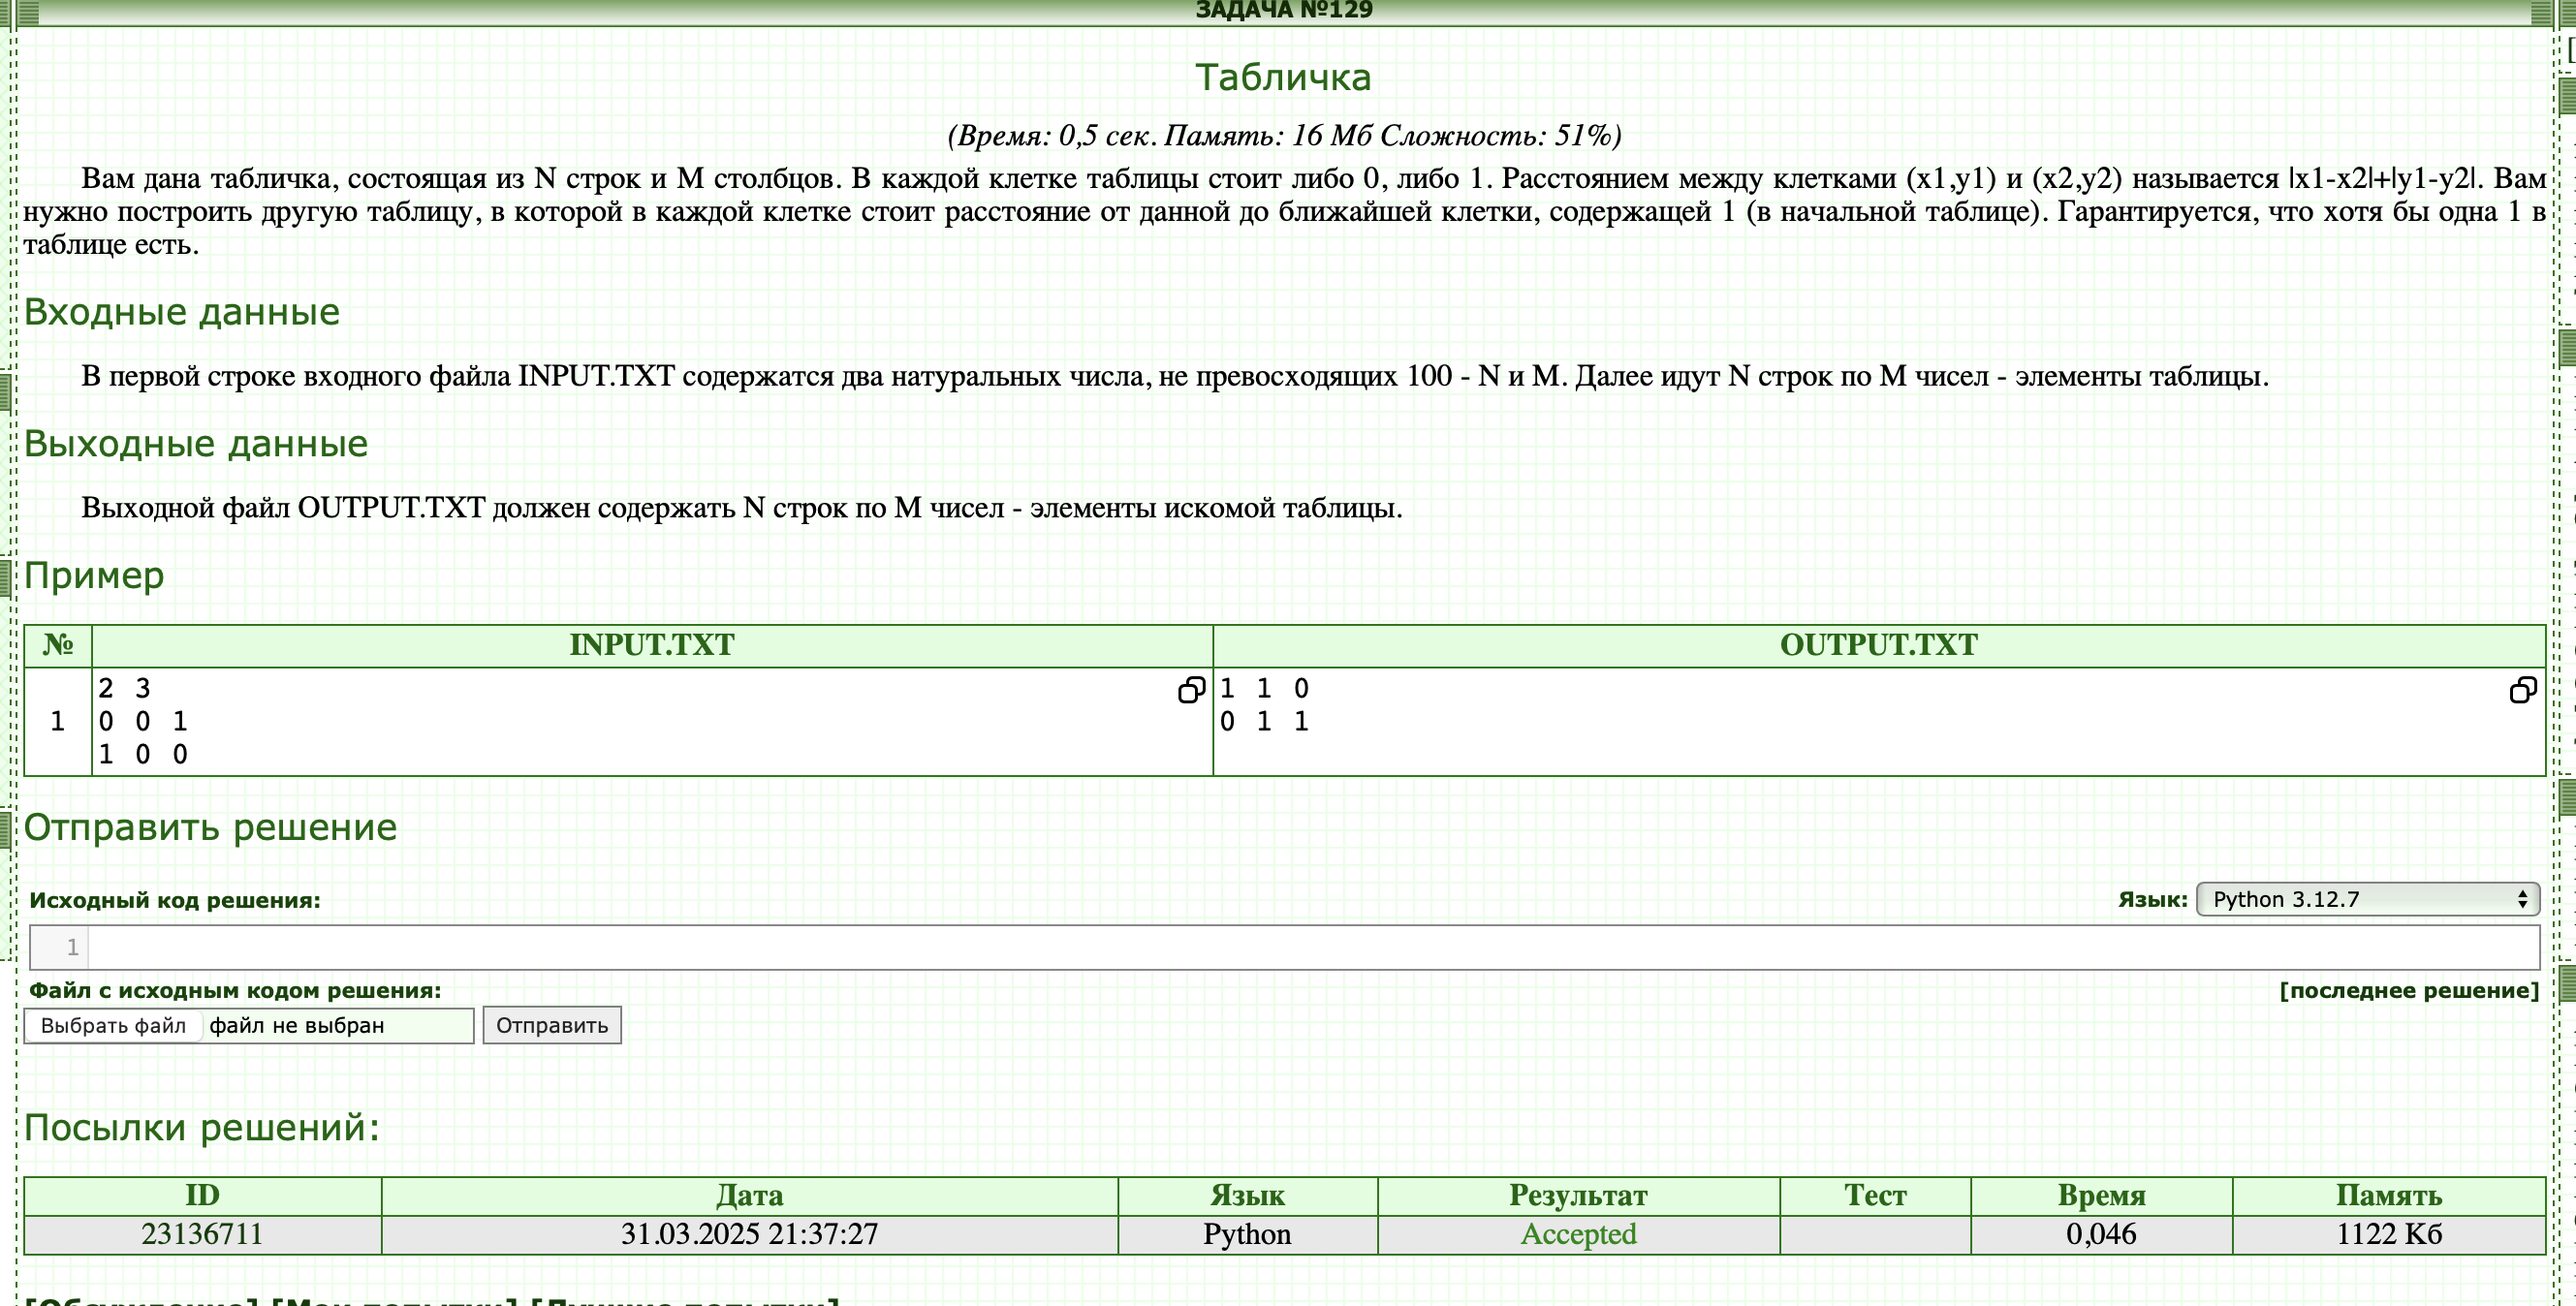

## Задача: Звезда ([ссылка](https://acmp.ru/asp/do/index.asp?main=task&id_course=2&id_section=21&id_topic=51&id_problem=652)) [0.5 балла]

Вам дана карта звёздного неба, представленная прямоугольной таблицей из N строк и M столбцов. Каждая ячейка таблицы может содержать один из двух символов:
- Точка (.) — означает отсутствие звезды.
- Звездочка (*) — означает наличие звезды.

**Созвездие** — это группа звёзд, которые соединены между собой по горизонтали или вертикали (то есть звёзды считаются соединёнными, если они являются соседями сверху, снизу, справа или слева). При этом одна изолированная звезда также считается созвездием.

**Задача:** Написать программу, которая подсчитывает количество созвездий на карте.

---

## Входные данные

- Первая строка входного файла `INPUT.TXT` содержит два натуральных числа N и M (N, M ≤ 300) — количество строк и столбцов карты.
- Далее следуют N строк, каждая из которых содержит M символов: «.» (точка) или «*» (звездочка).

---

## Выходные данные

Выведите одно число — количество созвездий на карте.

---

## Пример

**Входные данные:**
```
8 12
..**........
*..*..***...
*..*...*..*.
*****..*....
.......*...*
.......*..*.
....*.......
..********..
```

**Выходные данные:**
```
6
```

In [ ]:
# Асимптотическая сложность по времени - O(N × M)
# Асимптотическая сложность по памяти - O(N × M)

# ВАШ КОД
from collections import deque

def read_input():
    with open("INPUT.TXT", "r") as f:
        n, m = map(int, f.readline().split())
        grid = [list(f.readline().strip()) for _ in range(n)]
    return n, m, grid

def write_output(result):
    with open("OUTPUT.TXT", "w") as f:
        f.write(str(result) + "\n")

def count_constellations(n, m, grid):
    visited = [[False] * m for _ in range(n)]
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    def bfs(i, j):
        queue = deque()
        queue.append((i, j))
        visited[i][j] = True
        while queue:
            x, y = queue.popleft()
            for dx, dy in directions:
                nx, ny = x + dx, y + dy
                if 0 <= nx < n and 0 <= ny < m:
                    if not visited[nx][ny] and grid[nx][ny] == '*':
                        visited[nx][ny] = True
                        queue.append((nx, ny))

    count = 0
    for i in range(n):
        for j in range(m):
            if grid[i][j] == '*' and not visited[i][j]:
                bfs(i, j)
                count += 1
    return count

if __name__ == "__main__":
    n, m, grid = read_input()
    result = count_constellations(n, m, grid)
    write_output(result)


### ВАША интуиция
Каждое созвездие — это связная группа *, соединённая по сторонам, и мы просто считаем количество таких компонент, обходя карту с помощью BFS.

### ВАШ скрин ОКнутой задачи
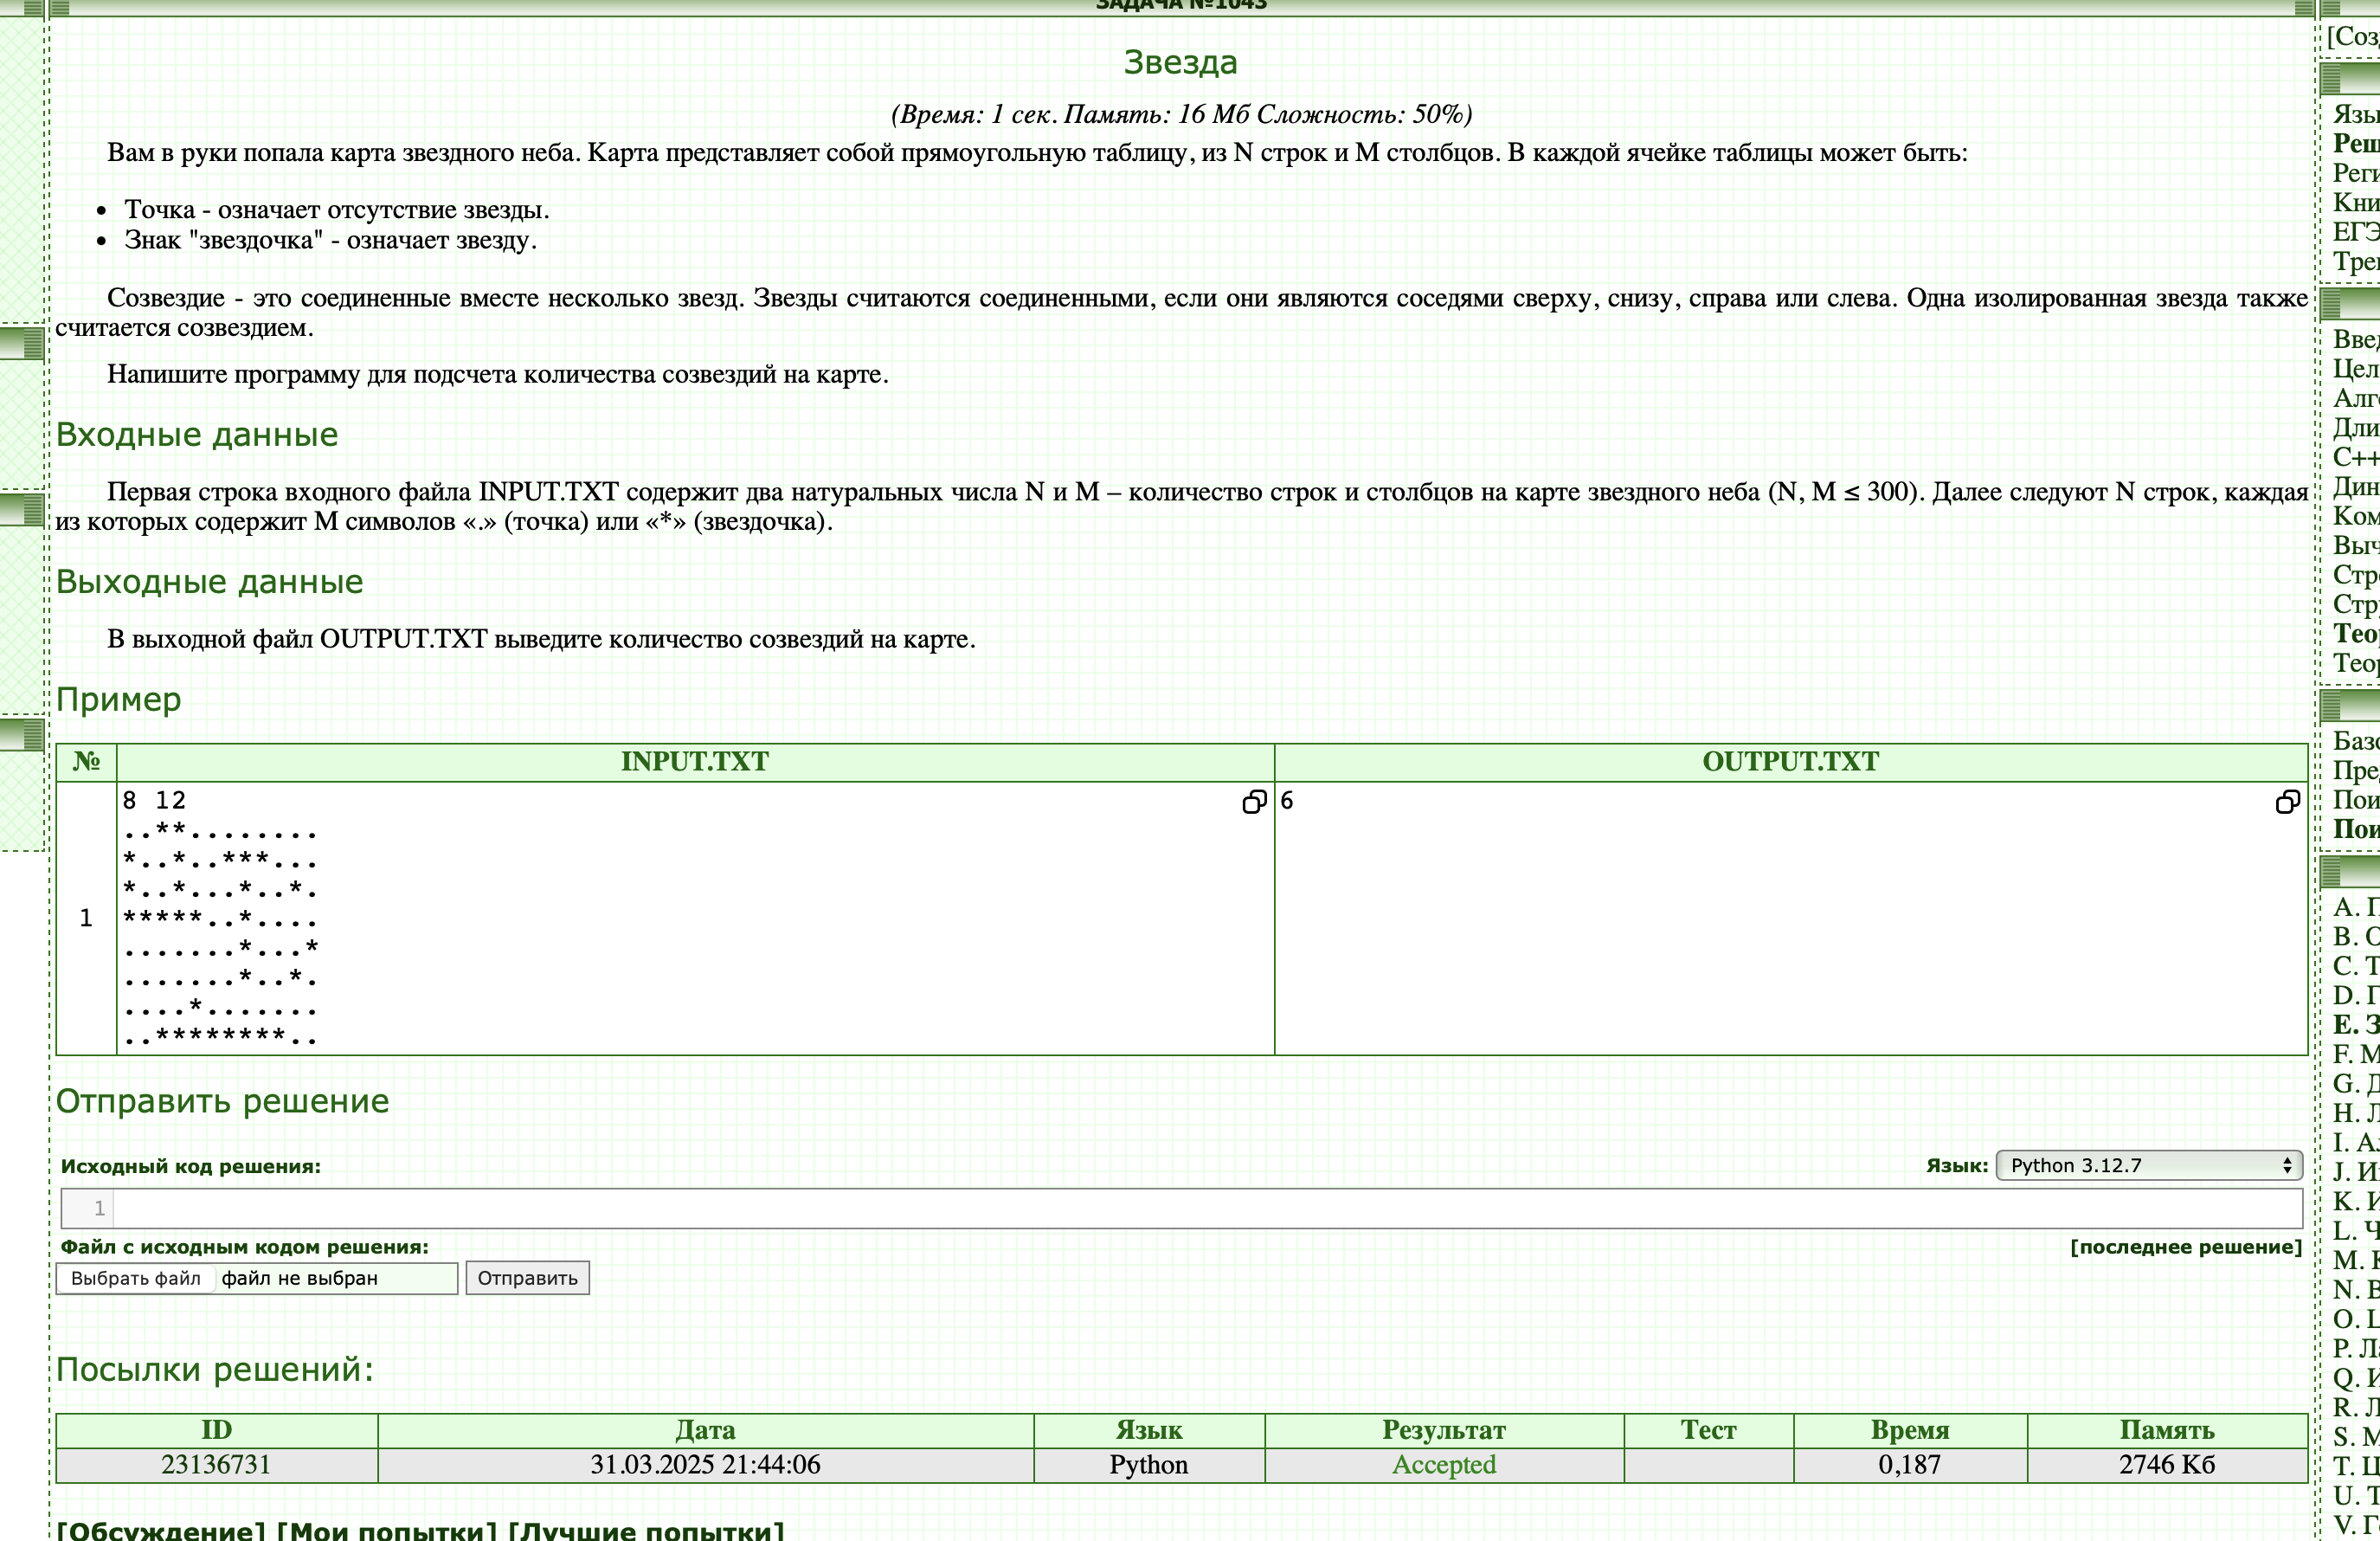

## Задача: Морской бой-3 ([ссылка](https://acmp.ru/asp/do/index.asp?main=task&id_course=2&id_section=21&id_topic=51&id_problem=653)) [0.5 балла]

Всем известна игра «Морской бой». В данной задаче поле имеет произвольные размеры N×M (1 ≤ N, M ≤ 10³). На поле расположены корабли, которые могут иметь любые формы и размеры. Корабль определяется как связная фигура клеток, соединённых по сторонам.

Каждая клетка игрового поля может содержать один из следующих символов:
- 'X' – подбитая клетка корабля;
- 'S' – не подбитая клетка корабля;
- '-' – свободная водная клетка.

**Задача:** Необходимо вывести три числа, разделённых пробелом:
1. Количество **целых кораблей** – корабли, у которых ни одна клетка не повреждена (все клетки обозначены символом 'S').
2. Количество **подбитых кораблей** – корабли, у которых имеются и подбитые ('X'), и неповреждённые ('S') клетки.
3. Количество **уничтоженных кораблей** – корабли, у которых все клетки подбиты (только символы 'X').

Корабли могут иметь любую форму, но клетки корабля соединены по сторонам.

---

## Входные данные

- Первая строка входного файла `INPUT.TXT` содержит два целых числа N и M (1 ≤ N, M ≤ 10³) – размеры игрового поля (N – число строк, M – число столбцов).
- Далее следуют N строк, каждая из которых содержит M символов – описание игрового поля.

---

## Выходные данные

Выведите в выходной файл `OUTPUT.TXT` через пробел три числа:
- количество целых кораблей,
- количество подбитых кораблей,
- количество уничтоженных кораблей.

---

## Пример

**Входные данные:**
```
3 8
---SSS--
XX--S-X-
X-S---S-
```

**Выходные данные:**
```
2 1 1
```

In [ ]:
# Асимптотическая сложность по времени - O(N × M)
# Асимптотическая сложность по памяти - O(N × M)

# ВАШ КОД

from collections import deque

def read_input():
    with open("INPUT.TXT", "r") as f:
        n, m = map(int, f.readline().split())
        grid = [list(f.readline().strip()) for _ in range(n)]
    return n, m, grid

def write_output(whole, damaged, destroyed):
    with open("OUTPUT.TXT", "w") as f:
        f.write(f"{whole} {damaged} {destroyed}\n")

def analyze_battlefield(n, m, grid):
    visited = [[False] * m for _ in range(n)]
    dirs = [(-1,0), (1,0), (0,-1), (0,1)]

    whole = damaged = destroyed = 0

    def bfs(x, y):
        queue = deque()
        queue.append((x, y))
        visited[x][y] = True
        s_count = 0
        x_count = 0

        while queue:
            cx, cy = queue.popleft()
            if grid[cx][cy] == 'S':
                s_count += 1
            elif grid[cx][cy] == 'X':
                x_count += 1

            for dx, dy in dirs:
                nx, ny = cx + dx, cy + dy
                if 0 <= nx < n and 0 <= ny < m:
                    if not visited[nx][ny] and grid[nx][ny] in {'S', 'X'}:
                        visited[nx][ny] = True
                        queue.append((nx, ny))
        return s_count, x_count

    for i in range(n):
        for j in range(m):
            if not visited[i][j] and grid[i][j] in {'S', 'X'}:
                s, x_ = bfs(i, j)
                if s > 0 and x_ == 0:
                    whole += 1
                elif s > 0 and x_ > 0:
                    damaged += 1
                elif s == 0 and x_ > 0:
                    destroyed += 1

    return whole, damaged, destroyed

if __name__ == "__main__":
    n, m, grid = read_input()
    whole, damaged, destroyed = analyze_battlefield(n, m, grid)
    write_output(whole, damaged, destroyed)



### ВАША интуиция

Каждый корабль — это связная группа клеток 'S' и 'X', соединённых по сторонам, и тип корабля определяется по составу клеток:

если все 'S' → целый,
если все 'X' → уничтожен,
если оба типа → подбит.

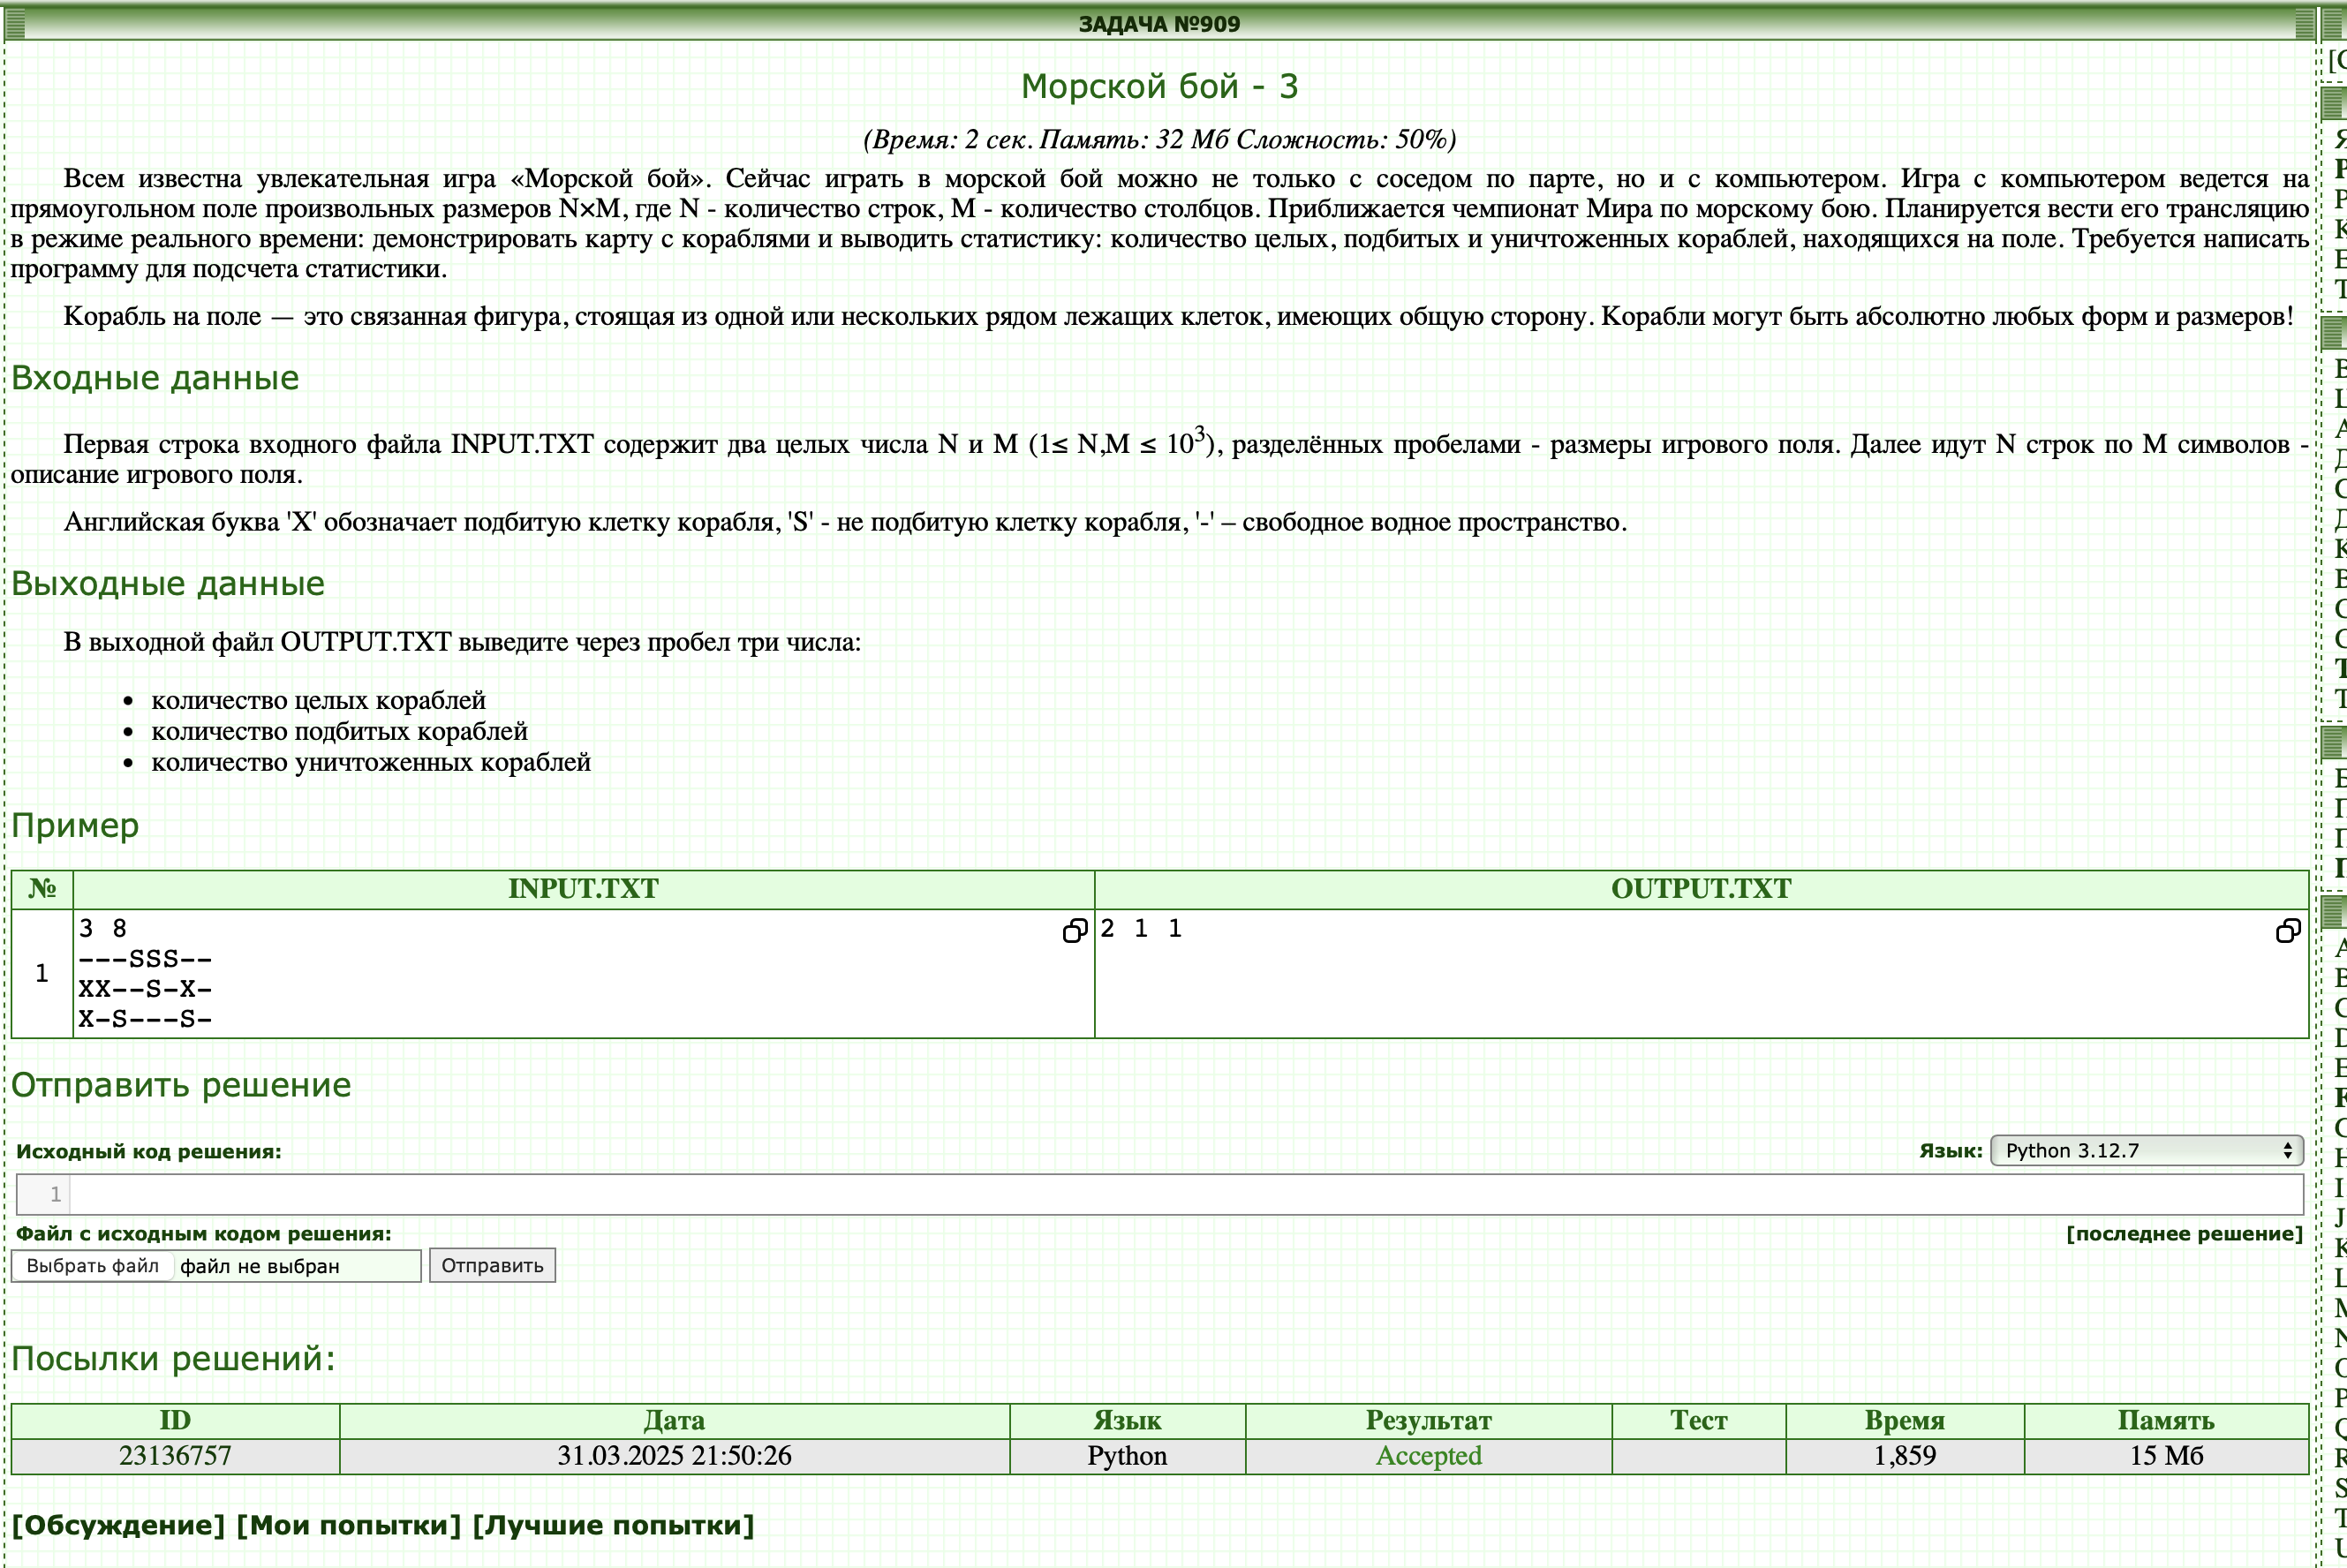